<div style="background:linear-gradient(135deg,#083344 0%,#0e7490 55%,#06b6d4 100%);border-radius:18px;padding:34px 30px;color:#fff;font-family:Inter,Segoe UI,sans-serif">
  <div style="font-size:12px;letter-spacing:3px;color:#a5f3fc;font-weight:700;text-transform:uppercase">Chapter 85 · Case Study · Inference</div>
  <div style="font-size:33px;font-weight:900;line-height:1.1;margin:10px 0 6px">Case Study: Comparing Marketing Channels 📣</div>
  <div style="font-size:15px;color:#ecfeff;max-width:760px;line-height:1.6">Four acquisition channels, one numeric outcome, and a budget on the line. We use one-way ANOVA to ask whether any channel truly differs, cross-check with a rank-based test, and let Tukey HSD name the winner.</div>
  <div style="margin-top:16px;font-size:13px;color:#a5f3fc">Statistics, Data Science and AI: A Visual Handbook · John Fisher · 2026</div>
</div>

## ⚙️ Setup

In [1]:
import numpy as np, pandas as pd, matplotlib.pyplot as plt
from scipy import stats
CY="#0891b2"; DEEP="#0e7490"; LIGHT="#67e8f9"; INK="#1a2138"; GRID="#e6e9f2"; GREEN="#059669"; RED="#ef4444"; AMBER="#d97706"
plt.rcParams.update({"figure.facecolor":"white","axes.facecolor":"white","figure.dpi":110,"font.size":11,
   "axes.edgecolor":GRID,"axes.grid":True,"grid.color":GRID,"axes.axisbelow":True,"axes.spines.top":False,
   "axes.spines.right":False,"axes.titlesize":12,"axes.titleweight":"bold","legend.frameon":False})
BASE="https://raw.githubusercontent.com/johnfisher-ai/Statistics-Data-Science-AI-Visual-Book/main/data/"
rng = np.random.default_rng(85)

<div style="background:#ecfeff;border-left:5px solid #0891b2;border-radius:10px;padding:16px 20px;font-family:Inter,sans-serif">
<span style="font-size:13px;font-weight:800;color:#0e7490;letter-spacing:1px">STEP 1 · THE QUESTION & THE DATA</span>
<div style="font-size:21px;font-weight:800;color:#1a2138;margin-top:4px">Which of four marketing channels brings the best customers?</div>
<div style="color:#4a5578;margin-top:6px">Marketing acquired customers through four channels and tracked each customer's 90-day revenue. The question: do the channels differ in average revenue per customer, and if so, which is best, so budget can be reallocated?</div>
</div>

In [2]:
try:    d = pd.read_excel("../../data/ch85_marketing_channels.xlsx", sheet_name="Customers")
except FileNotFoundError: d = pd.read_excel(BASE+"ch85_marketing_channels.xlsx", sheet_name="Customers")
print("loaded:", d.shape)
summ=d.groupby("channel").revenue_per_customer.agg(["size","mean","std"]).round(1)
print(summ.sort_values("mean", ascending=False))

loaded: (280, 4)
             size  mean   std
channel                      
Email          70  92.2  29.8
Organic        70  77.6  24.8
Paid Search    70  69.9  25.6
Social         70  67.3  25.7


Email looks highest (about 92 dollars per customer) and Social lowest (about 67), but four sample means always differ a little by chance. The question is whether ANY real difference exists, and then which channels truly stand apart.

<div style="background:#ecfeff;border-left:5px solid #0891b2;border-radius:10px;padding:16px 20px;font-family:Inter,sans-serif">
<span style="font-size:13px;font-weight:800;color:#0e7490;letter-spacing:1px">STEP 2 · CHOOSE THE TEST & STATE THE HYPOTHESES</span>
<div style="font-size:21px;font-weight:800;color:#1a2138;margin-top:4px">A numeric outcome across four groups</div>
<div style="color:#4a5578;margin-top:6px">Outcome = revenue (numeric). FOUR independent groups. Running all six pairwise t-tests would inflate the false-alarm rate, so the right omnibus test is ONE-WAY ANOVA. A significant F then earns a Tukey HSD post-hoc to find which pairs differ.</div>
</div>

In [3]:
print("Decision: numeric outcome + 4 independent groups -> ONE-WAY ANOVA (+ Tukey HSD post-hoc)")
print("H0: mu_Organic = mu_Paid = mu_Email = mu_Social  (all channels equal)")
print("H1: at least one channel mean differs")
# assumption sanity-check: group sizes and skew
for ch,g in d.groupby("channel"): print(f"  {ch:>12}: n={len(g)}, skew={stats.skew(g.revenue_per_customer):.2f}")
print("groups are balanced and only mildly skewed -> ANOVA is appropriate; we will also cross-check with Kruskal-Wallis")

Decision: numeric outcome + 4 independent groups -> ONE-WAY ANOVA (+ Tukey HSD post-hoc)
H0: mu_Organic = mu_Paid = mu_Email = mu_Social  (all channels equal)
H1: at least one channel mean differs
         Email: n=70, skew=-0.13
       Organic: n=70, skew=-0.04
   Paid Search: n=70, skew=0.15
        Social: n=70, skew=-0.18
groups are balanced and only mildly skewed -> ANOVA is appropriate; we will also cross-check with Kruskal-Wallis


Because revenue can be right-skewed, we will confirm the ANOVA verdict with the rank-based Kruskal-Wallis test, if both agree, the conclusion is robust to the normality assumption.

<div style="background:#ecfeff;border-left:5px solid #0891b2;border-radius:10px;padding:16px 20px;font-family:Inter,sans-serif">
<span style="font-size:13px;font-weight:800;color:#0e7490;letter-spacing:1px">STEP 3 · RUN THE ANALYSIS</span>
<div style="font-size:21px;font-weight:800;color:#1a2138;margin-top:4px">ANOVA, the rank-based cross-check, and Tukey HSD</div>
<div style="color:#4a5578;margin-top:6px">We run the F-test, report the effect size (eta-squared = share of revenue variance explained by channel), confirm with Kruskal-Wallis, then use Tukey HSD to pinpoint which channels separate.</div>
</div>

In [4]:
groups=[g.revenue_per_customer.values for _,g in d.groupby("channel")]
names=list(d.groupby("channel").groups.keys())
F,p=stats.f_oneway(*groups)
grand=d.revenue_per_customer.mean(); ssb=sum(len(g)*(g.mean()-grand)**2 for g in groups); sst=((d.revenue_per_customer-grand)**2).sum()
print(f"ANOVA: F={F:.2f}, p={p:.2e}, eta^2={ssb/sst:.3f}  -> {'reject H0' if p<0.05 else 'fail to reject'}")
print(f"Kruskal-Wallis cross-check: H={stats.kruskal(*groups).statistic:.2f}, p={stats.kruskal(*groups).pvalue:.2e} (agrees)")

ANOVA: F=12.44, p=1.18e-07, eta^2=0.119  -> reject H0
Kruskal-Wallis cross-check: H=29.72, p=1.58e-06 (agrees)


In [5]:
def tukey_hsd(groups, names, alpha=0.05):
    from scipy.stats import studentized_range
    k=len(groups); N=sum(len(g) for g in groups); dfw=N-k
    ssw=sum(((g-g.mean())**2).sum() for g in groups); msw=ssw/dfw
    qcrit=studentized_range.ppf(1-alpha, k, dfw)
    for i in range(k):
        for j in range(i+1,k):
            diff=groups[i].mean()-groups[j].mean()
            hsd=qcrit*np.sqrt(msw/2*(1/len(groups[i])+1/len(groups[j])))
            sig="YES" if abs(diff)>hsd else "no"
            print(f"  {names[i]:>12} vs {names[j]:<12} diff={diff:+6.1f}  95% CI [{diff-hsd:+6.1f},{diff+hsd:+6.1f}]  differ={sig}")

Tukey HSD (which channels differ?):
         Email vs Organic      diff= +14.6  95% CI [  +3.0, +26.2]  differ=YES
         Email vs Paid Search  diff= +22.3  95% CI [ +10.7, +34.0]  differ=YES
         Email vs Social       diff= +24.9  95% CI [ +13.3, +36.5]  differ=YES
       Organic vs Paid Search  diff=  +7.7  95% CI [  -3.9, +19.3]  differ=no
       Organic vs Social       diff= +10.3  95% CI [  -1.3, +21.9]  differ=no
   Paid Search vs Social       diff=  +2.6  95% CI [  -9.0, +14.2]  differ=no


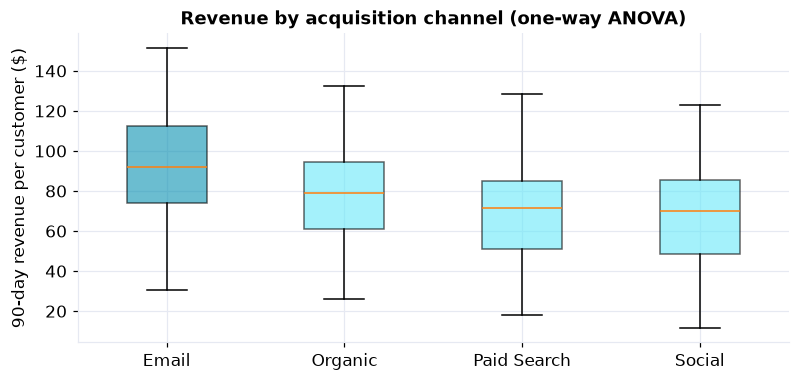

In [6]:
print("Tukey HSD (which channels differ?):"); tukey_hsd(groups, names)
fig,ax=plt.subplots(figsize=(7.4,3.6))
order=d.groupby("channel").revenue_per_customer.mean().sort_values(ascending=False).index.tolist()
bp=ax.boxplot([d[d.channel==c].revenue_per_customer.values for c in order], tick_labels=order, patch_artist=True)
for patch,c in zip(bp["boxes"],[CY,LIGHT,LIGHT,LIGHT]): patch.set_facecolor(c); patch.set_alpha(0.6)
ax.set_ylabel("90-day revenue per customer ($)"); ax.set_title("Revenue by acquisition channel (one-way ANOVA)")
plt.tight_layout(); plt.show()

The F-test is decisive (F &#8776; 12.4, p &#8776; 10&#8315;&#8311;), channel explains about <strong>12%</strong> of the variation in revenue, and Kruskal-Wallis agrees. Tukey HSD shows the whole story is <strong>Email</strong>: it beats each of the other three channels significantly, while Organic, Paid Search, and Social are statistically indistinguishable from one another.

<div style="background:#ffffff;border:1px solid #cffafe;border-left:5px solid #0e7490;border-radius:12px;padding:18px 22px;font-family:Inter,sans-serif">
<div style="font-size:12px;font-weight:800;color:#0e7490;letter-spacing:1px">📋 STATISTICIAN’S REPORT</div>
<div style="font-size:18px;font-weight:800;color:#1a2138;margin:4px 0 8px">Recommendation: shift budget toward Email</div>
<div style="color:#3f4a63;line-height:1.75"><strong>What we found.</strong> Customers acquired through <strong>Email</strong> are worth about <strong>$92</strong> in their first 90 days, roughly <strong>$15 to $25 more</strong> than those from Organic ($78), Paid Search ($70), or Social ($67). The other three channels are about the same as each other. <br><br><strong>How confident are we?</strong> The overall difference is highly unlikely to be chance (p &#8776; 0.0000001), and a rank-based cross-check agrees, so the finding does not depend on assuming a perfect bell curve. The pairwise comparisons (which control for testing several at once) confirm Email stands apart from all three others, while the gaps among Organic, Paid, and Social are within the noise. <br><br><strong>What to do.</strong> Re-weight acquisition spend toward Email, and treat Organic, Paid, and Social as interchangeable on revenue for now. <strong>Caveats:</strong> this is revenue per acquired customer, not per dollar spent, fold in each channel's acquisition cost before finalizing budget, and remember this is observational (channels were not randomly assigned), so self-selection could play a role.</div>
</div>

---
<div style="text-align:center;color:#8b94b3;font-size:12px;margin-top:10px">Statistics, Data Science and AI: A Visual Handbook · © 2026 John Fisher</div>